# Curling NN scaling laws

Train value networks across dataset sizes and hidden-layer widths. A fixed 30k-row validation set is used for every checkpoint.

In [24]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / 'curling_nn.py').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / 'scratch'))
import dataset
import constants
import scaling_laws

weights_dir = repo_root / 'weights' / 'scaling_laws_old'
validation_size = 30_000
num_epochs = 30
batch_size = 1_000
initial_learning_rate = 1

In [25]:
value_data = dataset.load_training_data_dir(constants.value_network_datasets_dir)
training_pool, validation_data = scaling_laws.make_scaling_splits(
    value_data, validation_size=validation_size,
    max_training_size=300_000, seed=2026
)
print(f'training pool: {training_pool.size():,} rows')
print(f'fixed validation set: {validation_data.size():,} rows')

training pool: 300,000 rows
fixed validation set: 30,000 rows


In [26]:
checkpoint_paths = scaling_laws.train_sweep(
    training_pool,
    weights_dir=weights_dir,
    training_sizes=(1_000, 3_000, 10_000, 30_000, 100_000, 300_000),
    hidden_layer_sizes=(10,18,30, 54,100),
    hidden_layer_sizes_by_training_size={300000: (10, 18, 30)},
    num_epochs=num_epochs,
    batch_size=batch_size,
    initial_learning_rate=initial_learning_rate,
)
print(f'{len(checkpoint_paths)} checkpoints available in {weights_dir}')

28 checkpoints available in /home/vietafan/curling/weights/scaling_laws_old


In [27]:
results = scaling_laws.evaluate_sweep(
    checkpoint_paths, validation_data, num_bootstrap_samples=100
)
results

ValueNetwork: 9 input stones, hidden layer size 10
  linear layer 0: weights (10, 46), bias (10, 1), parameters 470
  linear layer 1: weights (10, 10), bias (10, 1), parameters 110
  linear layer 2: weights (10, 10), bias (10, 1), parameters 110
  linear layer 3: weights (11, 10), bias (11, 1), parameters 121
total trainable parameters: 811
ValueNetwork: 9 input stones, hidden layer size 18
  linear layer 0: weights (18, 46), bias (18, 1), parameters 846
  linear layer 1: weights (18, 18), bias (18, 1), parameters 342
  linear layer 2: weights (18, 18), bias (18, 1), parameters 342
  linear layer 3: weights (11, 18), bias (11, 1), parameters 209
total trainable parameters: 1739
ValueNetwork: 9 input stones, hidden layer size 30
  linear layer 0: weights (30, 46), bias (30, 1), parameters 1410
  linear layer 1: weights (30, 30), bias (30, 1), parameters 930
  linear layer 2: weights (30, 30), bias (30, 1), parameters 930
  linear layer 3: weights (11, 30), bias (11, 1), parameters 341
t

path,training_size,hidden_layer_size,num_parameters,r_squared,negative_log_probability
str,i64,i64,i64,f64,f64
"""/home/vietafan/curling/weights…",1000,10,811,0.244755,1.393198
"""/home/vietafan/curling/weights…",1000,18,1739,0.276581,1.36853
"""/home/vietafan/curling/weights…",1000,30,3611,0.199589,1.419794
"""/home/vietafan/curling/weights…",1000,54,9083,0.104999,1.478039
"""/home/vietafan/curling/weights…",1000,100,26011,0.253064,1.432057
…,…,…,…,…,…
"""/home/vietafan/curling/weights…",100000,54,9083,0.610543,0.900476
"""/home/vietafan/curling/weights…",100000,100,26011,0.618113,0.889621
"""/home/vietafan/curling/weights…",300000,10,811,0.572461,0.984298


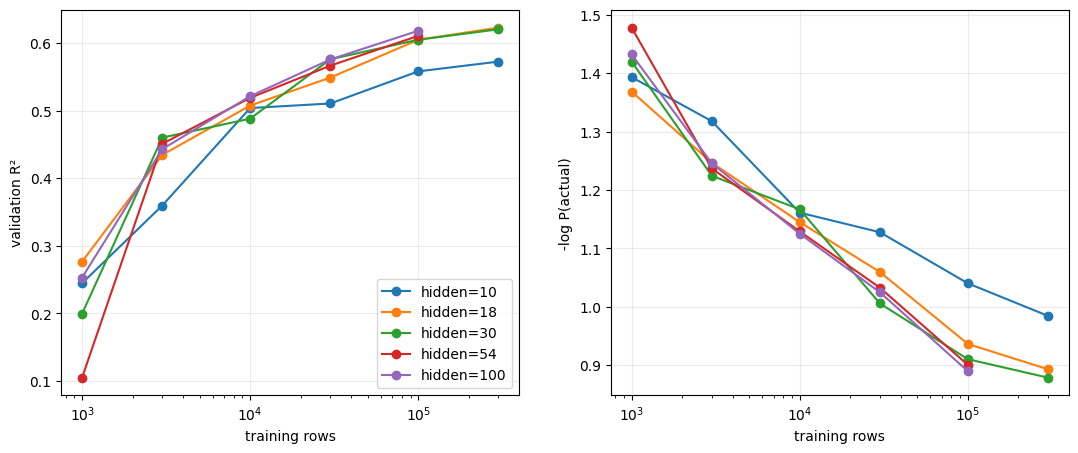

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for hidden_size, group in results.group_by('hidden_layer_size', maintain_order=True):
    label = f'hidden={hidden_size[0]}'
    axes[0].plot(group['training_size'], group['r_squared'], 'o-', label=label)
    axes[1].plot(group['training_size'], group['negative_log_probability'], 'o-', label=label)
for ax, ylabel in zip(axes, ['validation R²', '-log P(actual)']):
    ax.set(xscale='log', xlabel='training rows', ylabel=ylabel)
    ax.grid(alpha=0.25)
axes[0].legend()
plt.show()

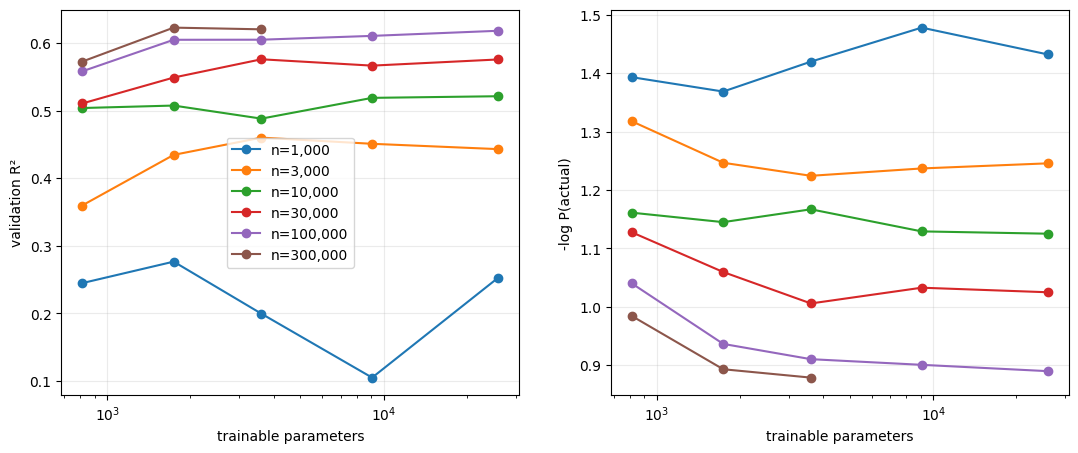

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for training_size, group in results.group_by('training_size', maintain_order=True):
    label = f'n={training_size[0]:,}'
    axes[0].plot(group['num_parameters'], group['r_squared'], 'o-', label=label)
    axes[1].plot(group['num_parameters'], group['negative_log_probability'], 'o-', label=label)
for ax, ylabel in zip(axes, ['validation R²', '-log P(actual)']):
    ax.set(xscale='log', xlabel='trainable parameters', ylabel=ylabel)
    ax.grid(alpha=0.25)
axes[0].legend()
plt.show()

## Second-to-last policy comparison

For each checkpoint, compare value-network selection with actual-score grid-search selection on the second-to-last throw. Both policies use exactly the same candidate throw grid on each sheet state, and both use actual-score grid search for the final throw.

In [ ]:
import evaluation

second_to_last_states = evaluation.load_sheet_states(
    repo_root / 'scratch/second_to_last_evaluation_states.npz'
)
policy_results = scaling_laws.evaluate_second_to_last_policy_sweep(
    checkpoint_paths, second_to_last_states, second_to_last_team=1
)
policy_results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (hidden_size, policy), group in policy_results.group_by(
    ['hidden_layer_size', 'second_to_last_policy'], maintain_order=True
): 
    label = f'hidden={hidden_size[0]}, {policy[0]}'
    axes[0].errorbar(group['training_size'], group['average_points'], yerr=group['points_stderr'], fmt='o-', label=label)
    axes[1].errorbar(group['num_parameters'], group['average_points'], yerr=group['points_stderr'], fmt='o-', label=label)
for ax in axes:
    ax.set(xscale='log', xlabel='training rows', ylabel='average points scored')
    ax.grid(alpha=0.25)
axes[0].set_title('Second-to-last policy vs training size')
axes[1].set_title('Second-to-last policy vs parameter count')
axes[1].set_xlabel('trainable parameters')
for ax in axes: ax.legend()
plt.show()